In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings("ignore")

# Set style for better plots
plt.style.use("default")
sns.set_palette("husl")

In [ ]:
df = pd.read_csv(
    "/home/robbe/MuMDIA/results/ecoli_debug_fragments_fixed/outfile.pin", sep="\t"
)

df_working = pd.read_csv(
    "/home/robbe/MuMDIA/results/ecoli_debug_fragments_fixed/outfilebeforenonsquaring.pin",
    sep="\t",
)

In [13]:
df

,ScanNr,filename,Peptide,num_proteins,Proteins,ExpMass,CalcMass,Label,charge,peptide_len,...,top_correlation_individual_1,top_correlation_individual_2,top_correlation_individual_3,top_correlation_individual_4,top_correlation_individual_5,top_correlation_individual_6,top_correlation_individual_7,top_correlation_individual_8,top_correlation_individual_9,top_correlation_individual_10
0,152761.0,part_4257.031860351558_5321.289825439448.mzml,GASHEFESRAVVTDYSIDSVGSLR,1.0,rev_sp|P0A6W0|GLSA2_ECOLI|143|167,2574.14230,2581.2405,-1.0,4.0,24.0,...,0.194087,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,92850.0,part_3192.7738952636682_4257.031860351558.mzml,VAEARTM[Oxidation]SISQALEADGRVK,1.0,rev_sp|P24182|ACCC_ECOLI|170|190,2146.70480,2147.1003,-1.0,3.0,20.0,...,0.277861,0.272848,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,33953.0,part_2128.5159301757785_3192.7738952636682.mzml,NFGPGGM[Oxidation]SPGGSSR,1.0,rev_sp|P64429|YPFJ_ECOLI|16|30,1330.33400,1322.5673,-1.0,3.0,14.0,...,0.233884,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,67992.0,part_3192.7738952636682_4257.031860351558.mzml,ATVRSNLRAHIGDIR,1.0,rev_sp|P76083|PAAH_ECOLI|43|58,1693.74220,1677.9385,-1.0,4.0,15.0,...,0.341612,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,96967.0,part_3192.7738952636682_4257.031860351558.mzml,VVQEKQHEQPDIDKALLR,1.0,rev_sp|P32053|INTA_ECOLI|79|97,2146.70480,2145.1540,-1.0,3.0,18.0,...,0.238119,0.183446,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81122,34906.0,part_2128.5159301757785_3192.7738952636682.mzml,YHLDDISMHR,1.0,sp|P18392|RSTB_ECOLI|84|94,1287.07120,1285.5873,1.0,2.0,10.0,...,0.576323,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
81123,36090.0,part_2128.5159301757785_3192.7738952636682.mzml,AGGDSLTFNK,1.0,rev_sp|P76347|YEEJ_ECOLI|1485|1495,1006.94385,1008.4876,-1.0,2.0,10.0,...,0.258456,0.226179,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
81124,284901.0,part_6385.547790527337_7449.805755615227.mzml,YPQCQRVDSKLIETWFNNLNWGPDK,1.0,sp|Q46911|YGCU_ECOLI|307|332,3054.36060,3050.4710,1.0,4.0,25.0,...,0.575740,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
81125,52608.0,part_3192.7738952636682_4257.031860351558.mzml,AKQSPNTM[Oxidation]SDM[Oxidation]AAFEK,1.0,sp|P0ABJ1|CYOA_ECOLI|237|253,1786.54130,1786.7865,1.0,3.0,16.0,...,0.346999,0.345073,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Show differencce in columns between the two dataframes
print("Columns in original dataframe:")
print(df.columns.tolist())
print("\nColumns in working dataframe:")
print(df_working.columns.tolist())

set1 = set(df.columns.tolist())
set2 = set(df_working.columns.tolist())
print("\nColumns in original but not in working dataframe:")
print(set1 - set2)
print("\nColumns in working but not in original dataframe:")
print(set2 - set1)

Columns in original dataframe:
['ScanNr', 'filename', 'Peptide', 'num_proteins', 'Proteins', 'ExpMass', 'CalcMass', 'Label', 'charge', 'peptide_len', 'missed_cleavages', 'fragment_ppm_max', 'rank_max', 'delta_next_max', 'delta_rt_model_max', 'matched_peaks_max', 'longest_b_max', 'longest_y_max', 'matched_intensity_pct_max', 'spectrum_q_max', 'peptide_q_max', 'rt_prediction_error_abs_relative_max', 'precursor_ppm_max', 'hyperscore_max', 'precursor_intensity_M_max', 'precursor_intensity_M+1_max', 'precursor_intensity_M-1_max', 'fragment_ppm_min', 'rank_min', 'delta_next_min', 'delta_rt_model_min', 'matched_peaks_min', 'longest_b_min', 'longest_y_min', 'matched_intensity_pct_min', 'fragment_intensity_min', 'poisson_min', 'spectrum_q_min', 'peptide_q_min', 'rt_min', 'rt_predictions_min', 'rt_prediction_error_abs_min', 'rt_prediction_error_abs_relative_min', 'precursor_ppm_min', 'hyperscore_min', 'delta_best_min', 'precursor_intensity_M_min', 'precursor_intensity_M+1_min', 'precursor_intens

In [15]:
df_targets = df[df["Label"] == 1.0]
df_decoys = df[df["Label"] == -1.0]
df_targets_working = df_working[df_working["Label"] == 1.0]
df_decoys_working = df_working[df_working["Label"] == -1.0]

In [16]:
df_targets

,ScanNr,filename,Peptide,num_proteins,Proteins,ExpMass,CalcMass,Label,charge,peptide_len,...,top_correlation_individual_1,top_correlation_individual_2,top_correlation_individual_3,top_correlation_individual_4,top_correlation_individual_5,top_correlation_individual_6,top_correlation_individual_7,top_correlation_individual_8,top_correlation_individual_9,top_correlation_individual_10
6,23520.0,part_2128.5159301757785_3192.7738952636682.mzml,QRTM[Oxidation]EVLR,1.0,sp|P29018|CYDD_ECOLI|236|244,1038.9584,1047.5494,1.0,2.0,8.0,...,0.755434,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
11,285502.0,part_7449.805755615226_8514.063720703116.mzml,TLFTVSAGGQPAYSQDFAPLPADIR,1.0,sp|P77581|ASTC_ECOLI|141|166,2638.1716,2621.3123,1.0,4.0,25.0,...,0.914916,0.899925,0.891114,0.855841,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
13,11947.0,part_2128.5159301757785_3192.7738952636682.mzml,STRSIGLTEAGR,1.0,sp|P67662|AAER_ECOLI|51|63,1234.2903,1246.6628,1.0,3.0,12.0,...,0.456828,0.382978,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
14,204229.0,part_5321.289825439448_6385.547790527337.mzml,CVLIFM[Oxidation]AEGNPRIAK,1.0,sp|Q46911|YGCU_ECOLI|280|295,1679.2494,1676.8743,1.0,2.0,15.0,...,-0.156183,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
15,251054.0,part_6385.547790527337_7449.805755615227.mzml,ADIQKLLTSLPAHHFQIVLEITER,1.0,sp|P76446|PDEN_ECOLI|367|391,2782.9941,2771.5330,1.0,3.0,24.0,...,0.207290,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81119,268843.0,part_6385.547790527337_7449.805755615227.mzml,AEQLEENVQALNNLTFSTK,1.0,sp|Q46851|GPR_ECOLI|304|323,2158.7104,2148.0700,1.0,3.0,19.0,...,0.897986,0.890794,0.885428,0.873590,0.865923,0.864530,0.836818,0.835746,0.802908,0.794334
81120,13391.0,part_2128.5159301757785_3192.7738952636682.mzml,GVHEGHVAAEVIAGK,1.0,sp|P0A9P0|DLDH_ECOLI|323|338,1471.1549,1472.7737,1.0,2.0,15.0,...,0.799558,0.789856,0.780487,0.763080,0.752697,0.709381,0.706739,0.706695,0.696861,0.692283
81122,34906.0,part_2128.5159301757785_3192.7738952636682.mzml,YHLDDISMHR,1.0,sp|P18392|RSTB_ECOLI|84|94,1287.0712,1285.5873,1.0,2.0,10.0,...,0.576323,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
81124,284901.0,part_6385.547790527337_7449.805755615227.mzml,YPQCQRVDSKLIETWFNNLNWGPDK,1.0,sp|Q46911|YGCU_ECOLI|307|332,3054.3606,3050.4710,1.0,4.0,25.0,...,0.575740,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [17]:
def compare_feature_distributions_side_by_side(
    df_targets1, df_decoys1, df_targets2, df_decoys2, selected_peptides=None, bins=100
):
    """
    Compare feature distributions for two sets of target/decoy dataframes.
    For each feature, show df1 (targets/decoys) on the left and df2 (targets/decoys) on the right.
    """
    import matplotlib.pyplot as plt
    import pandas as pd

    numeric_cols = [
        c for c in df_targets1.columns if pd.api.types.is_numeric_dtype(df_targets1[c])
    ]
    n_features = len(numeric_cols)
    fig, axes = plt.subplots(n_features, 2, figsize=(12, 4 * n_features), squeeze=False)

    for idx, c in enumerate(numeric_cols):
        # Left: df1
        ax1 = axes[idx, 0]
        ax1.hist(df_targets1[c].dropna(), alpha=0.5, bins=bins, label="Targets 1")
        ax1.hist(df_decoys1[c].dropna(), alpha=0.5, bins=bins, label="Decoys 1")
        ax1.set_title(f"{c} (df1)")
        ax1.legend()

        # Right: df2
        ax2 = axes[idx, 1]
        ax2.hist(df_targets2[c].dropna(), alpha=0.5, bins=bins, label="Targets 2")
        ax2.hist(df_decoys2[c].dropna(), alpha=0.5, bins=bins, label="Decoys 2")
        ax2.set_title(f"{c} (df2)")
        ax2.legend()

        # Optionally highlight selected peptides
        if selected_peptides is not None and "Peptide" in df_targets1.columns:
            for pep in selected_peptides:
                vals1 = df_targets1[df_targets1["Peptide"] == pep][c]
                vals2 = df_targets2[df_targets2["Peptide"] == pep][c]
                ax1.scatter(
                    vals1,
                    [ax1.get_ylim()[1] * 0.9] * len(vals1),
                    color="blue",
                    marker="x",
                )
                ax2.scatter(
                    vals2,
                    [ax2.get_ylim()[1] * 0.9] * len(vals2),
                    color="green",
                    marker="x",
                )

    plt.tight_layout()
    plt.show()

In [18]:
compare_feature_distributions_side_by_side(
    df_targets, df_decoys, df_targets_working, df_decoys_working
)

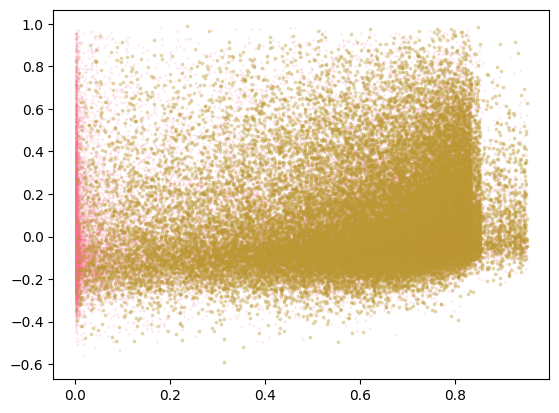

In [31]:
plt.scatter(
    df_targets["peptide_q_mean"],
    df_targets["distribution_correlation_individual_100"],
    alpha=0.1,
    s=1,
)
plt.scatter(
    df_decoys["peptide_q_mean"],
    df_decoys["distribution_correlation_individual_100"],
    alpha=0.3,
    s=3,
)

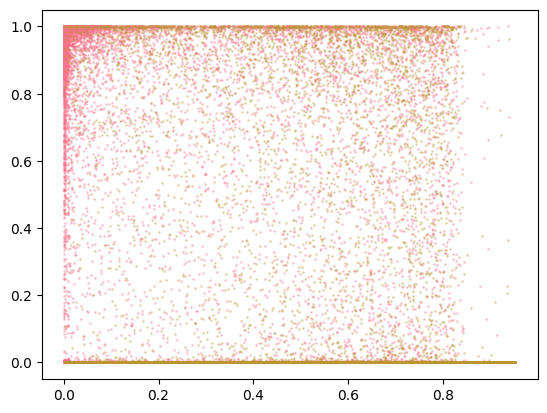

In [32]:
plt.scatter(
    df_targets["peptide_q_mean"],
    df_targets["top_correlation_matrix_psm_ids_3"],
    alpha=0.3,
    s=1,
)
plt.scatter(
    df_decoys["peptide_q_mean"],
    df_decoys["top_correlation_matrix_psm_ids_3"],
    alpha=0.3,
    s=1,
)

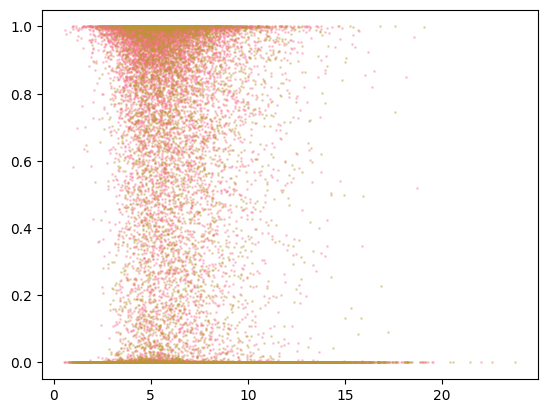

In [33]:
plt.scatter(
    df_targets["mse_avg_pred_intens_1"],
    df_targets["top_correlation_matrix_psm_ids_3"],
    alpha=0.3,
    s=1,
)
plt.scatter(
    df_decoys["mse_avg_pred_intens_1"],
    df_decoys["top_correlation_matrix_psm_ids_3"],
    alpha=0.3,
    s=1,
)

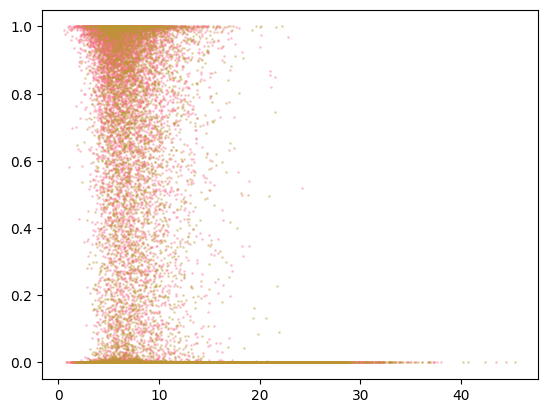

In [34]:
plt.scatter(
    df_targets["mse_avg_pred_intens_total_1"],
    df_targets["top_correlation_matrix_psm_ids_3"],
    alpha=0.3,
    s=1,
)
plt.scatter(
    df_decoys["mse_avg_pred_intens_total_1"],
    df_decoys["top_correlation_matrix_psm_ids_3"],
    alpha=0.3,
    s=1,
)

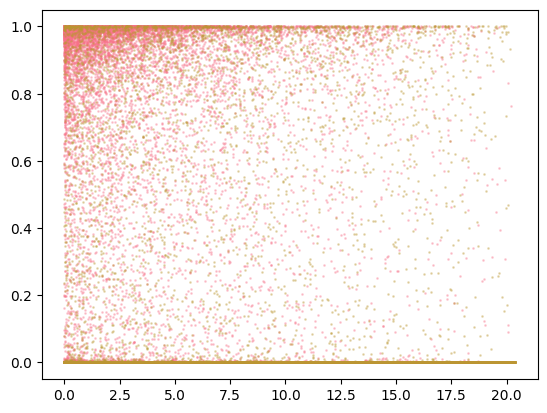

In [35]:
plt.scatter(
    df_targets["rt_prediction_error_abs_min"],
    df_targets["top_correlation_matrix_psm_ids_3"],
    alpha=0.3,
    s=1,
)
plt.scatter(
    df_decoys["rt_prediction_error_abs_min"],
    df_decoys["top_correlation_matrix_psm_ids_3"],
    alpha=0.3,
    s=1,
)

In [36]:
list(df_targets.columns)

['ScanNr',
 'filename',
 'Peptide',
 'num_proteins',
 'Proteins',
 'ExpMass',
 'CalcMass',
 'Label',
 'charge',
 'peptide_len',
 'missed_cleavages',
 'fragment_ppm_max',
 'rank_max',
 'delta_next_max',
 'delta_rt_model_max',
 'matched_peaks_max',
 'longest_b_max',
 'longest_y_max',
 'matched_intensity_pct_max',
 'spectrum_q_max',
 'peptide_q_max',
 'rt_prediction_error_abs_relative_max',
 'precursor_ppm_max',
 'hyperscore_max',
 'precursor_intensity_M_max',
 'precursor_intensity_M+1_max',
 'precursor_intensity_M-1_max',
 'fragment_ppm_min',
 'rank_min',
 'delta_next_min',
 'delta_rt_model_min',
 'matched_peaks_min',
 'longest_b_min',
 'longest_y_min',
 'matched_intensity_pct_min',
 'fragment_intensity_min',
 'poisson_min',
 'spectrum_q_min',
 'peptide_q_min',
 'rt_min',
 'rt_predictions_min',
 'rt_prediction_error_abs_min',
 'rt_prediction_error_abs_relative_min',
 'precursor_ppm_min',
 'hyperscore_min',
 'delta_best_min',
 'precursor_intensity_M_min',
 'precursor_intensity_M+1_min',
 

# Feature Analysis for Target/Decoy Separation

This section analyzes which features best separate targets from decoys using multiple approaches.

In [37]:
def analyze_feature_separability(df, target_label=1.0, decoy_label=-1.0):
    """
    Analyze how well each feature separates targets from decoys
    """
    results = []

    # Get numeric columns only
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    # Exclude the Label column
    feature_cols = [col for col in numeric_cols if col != "Label"]

    targets = df[df["Label"] == target_label]
    decoys = df[df["Label"] == decoy_label]

    for col in feature_cols:
        if col in targets.columns and col in decoys.columns:
            target_vals = targets[col].dropna()
            decoy_vals = decoys[col].dropna()

            if len(target_vals) > 0 and len(decoy_vals) > 0:
                # Statistical tests
                mannwhitney_stat, mannwhitney_p = stats.mannwhitneyu(
                    target_vals, decoy_vals, alternative="two-sided"
                )

                # Effect size (Cohen's d)
                pooled_std = np.sqrt(
                    (
                        (len(target_vals) - 1) * target_vals.var()
                        + (len(decoy_vals) - 1) * decoy_vals.var()
                    )
                    / (len(target_vals) + len(decoy_vals) - 2)
                )
                cohens_d = (
                    abs(target_vals.mean() - decoy_vals.mean()) / pooled_std
                    if pooled_std > 0
                    else 0
                )

                # ROC AUC for this feature alone
                try:
                    y_true = [1] * len(target_vals) + [0] * len(decoy_vals)
                    y_score = list(target_vals) + list(decoy_vals)
                    auc_score = roc_auc_score(y_true, y_score)
                except:
                    auc_score = 0.5

                # Separation ratio (difference in means / pooled standard deviation)
                separation_ratio = (
                    abs(target_vals.mean() - decoy_vals.mean()) / pooled_std
                    if pooled_std > 0
                    else 0
                )

                results.append(
                    {
                        "feature": col,
                        "target_mean": target_vals.mean(),
                        "target_std": target_vals.std(),
                        "decoy_mean": decoy_vals.mean(),
                        "decoy_std": decoy_vals.std(),
                        "mean_difference": abs(target_vals.mean() - decoy_vals.mean()),
                        "mannwhitney_p": mannwhitney_p,
                        "cohens_d": cohens_d,
                        "auc_score": auc_score,
                        "separation_ratio": separation_ratio,
                    }
                )

    return pd.DataFrame(results).sort_values("auc_score", ascending=False)


# Analyze feature separability
feature_analysis = analyze_feature_separability(df)
print("Top 15 features by AUC score for target/decoy separation:")
print(
    feature_analysis.head(15)[
        ["feature", "auc_score", "cohens_d", "mannwhitney_p", "separation_ratio"]
    ].round(4)
)

Top 15 features by AUC score for target/decoy separation:
                                        feature  auc_score  cohens_d  \
13                                longest_y_max     0.5942    0.4748   
50                    precursor_intensity_M_sum     0.5873    0.0599   
11                            matched_peaks_max     0.5864    0.4554   
51                  precursor_intensity_M+1_sum     0.5834    0.0549   
20                    precursor_intensity_M_max     0.5804    0.1147   
57  distribution_correlation_matrix_psm_ids_100     0.5790    0.3348   
73             top_correlation_matrix_psm_ids_1     0.5790    0.3348   
74             top_correlation_matrix_psm_ids_2     0.5790    0.3348   
47                   precursor_intensity_M_mean     0.5790    0.0703   
14                    matched_intensity_pct_max     0.5788    0.3605   
76             top_correlation_matrix_psm_ids_4     0.5784    0.4212   
75             top_correlation_matrix_psm_ids_3     0.5784    0.4212   
78    

In [38]:
# Feature importance using Random Forest
def get_feature_importance(df, target_label=1.0, decoy_label=-1.0):
    """
    Use Random Forest to determine feature importance for target/decoy classification
    """
    # Prepare data
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    feature_cols = [col for col in numeric_cols if col != "Label"]

    X = df[feature_cols].fillna(0)  # Fill NaN with 0
    y = (df["Label"] == target_label).astype(int)  # 1 for targets, 0 for decoys

    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Train Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
    rf.fit(X_scaled, y)

    # Get feature importance
    importance_df = pd.DataFrame(
        {"feature": feature_cols, "importance": rf.feature_importances_}
    ).sort_values("importance", ascending=False)

    return importance_df, rf.score(X_scaled, y)


importance_df, rf_accuracy = get_feature_importance(df)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print("\nTop 15 features by Random Forest importance:")
print(importance_df.head(15))

Random Forest Accuracy: 0.6389

Top 15 features by Random Forest importance:
                                 feature  importance
34                         peptide_q_min    0.108501
33                        spectrum_q_min    0.085377
16                         peptide_q_max    0.081872
46                        peptide_q_mean    0.056139
32                           poisson_min    0.047705
17  rt_prediction_error_abs_relative_max    0.041725
11                     matched_peaks_max    0.040859
19                        hyperscore_max    0.036093
45                       spectrum_q_mean    0.030642
37           rt_prediction_error_abs_min    0.027700
50             precursor_intensity_M_sum    0.027232
13                         longest_y_max    0.026746
38  rt_prediction_error_abs_relative_min    0.022123
82     top_correlation_matrix_psm_ids_10    0.021971
51           precursor_intensity_M+1_sum    0.018769


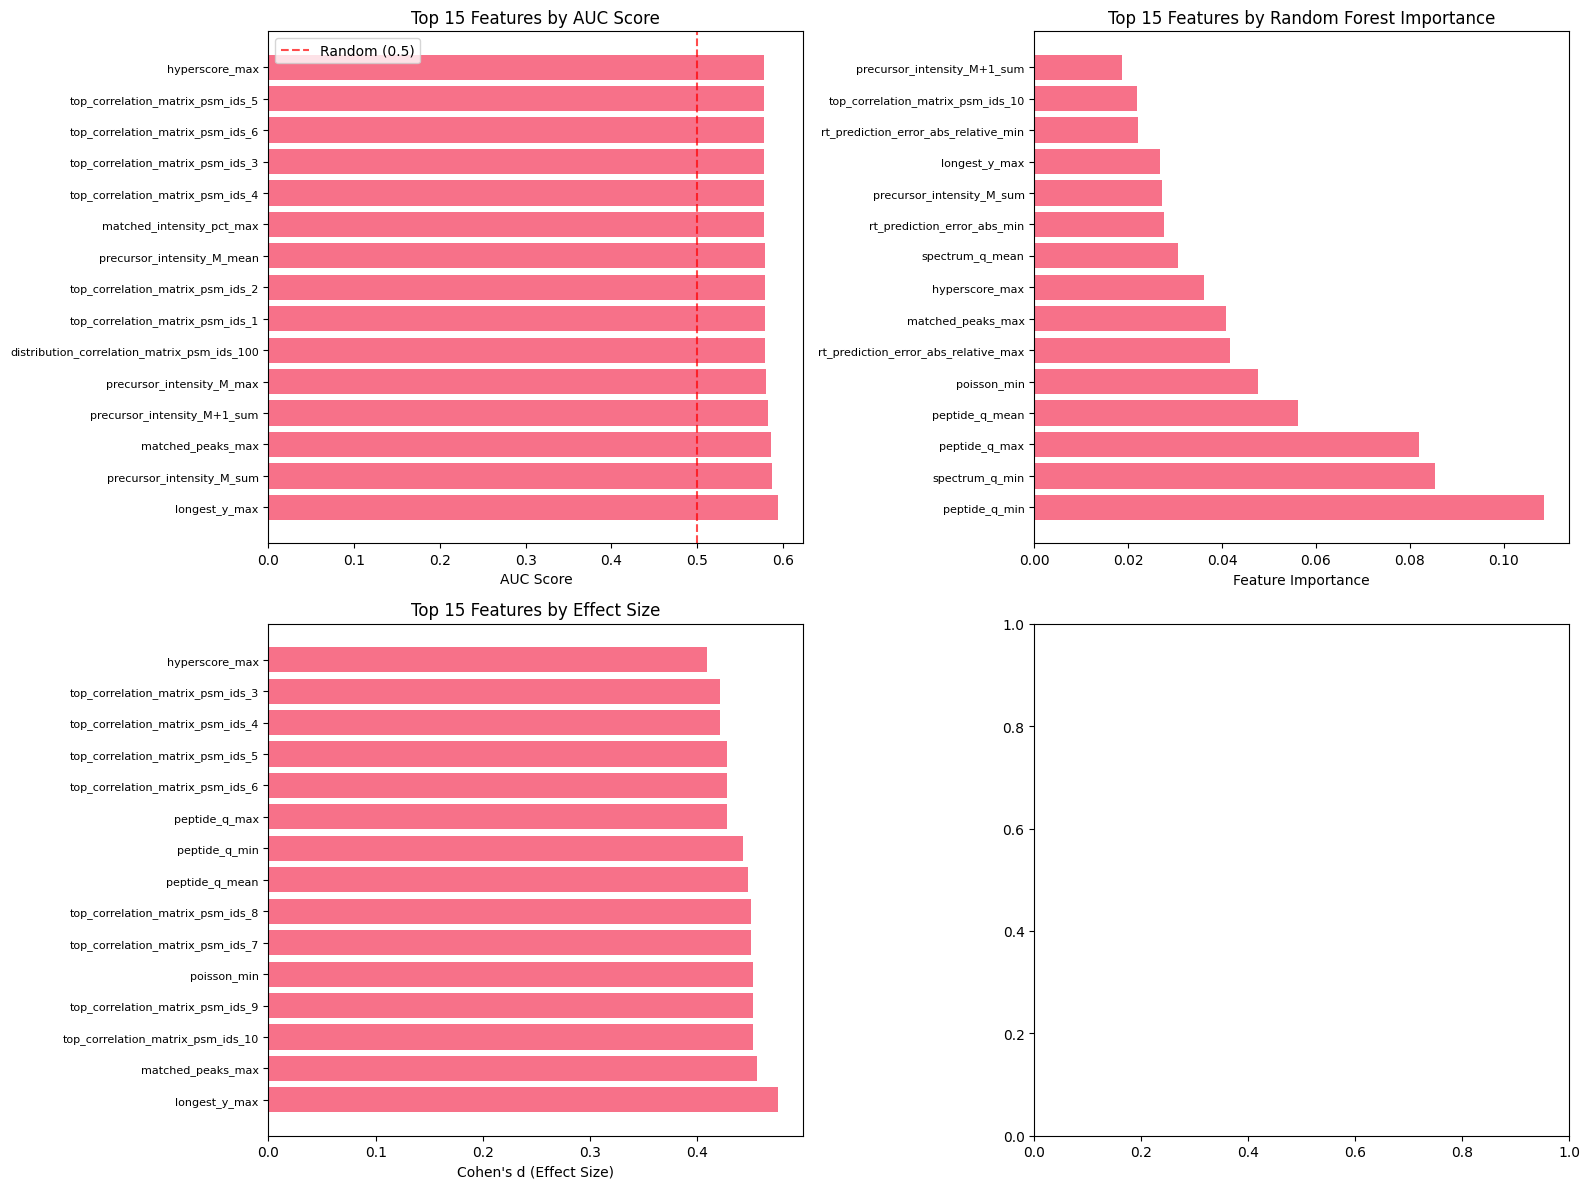

In [39]:
# Compare different feature ranking methods
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: AUC scores
top_auc = feature_analysis.head(15)
ax1.barh(range(len(top_auc)), top_auc["auc_score"])
ax1.set_yticks(range(len(top_auc)))
ax1.set_yticklabels(top_auc["feature"], fontsize=8)
ax1.set_xlabel("AUC Score")
ax1.set_title("Top 15 Features by AUC Score")
ax1.axvline(x=0.5, color="red", linestyle="--", alpha=0.7, label="Random (0.5)")
ax1.legend()

# Plot 2: Random Forest importance
top_rf = importance_df.head(15)
ax2.barh(range(len(top_rf)), top_rf["importance"])
ax2.set_yticks(range(len(top_rf)))
ax2.set_yticklabels(top_rf["feature"], fontsize=8)
ax2.set_xlabel("Feature Importance")
ax2.set_title("Top 15 Features by Random Forest Importance")

# Plot 3: Cohen's d (effect size)
top_cohens = feature_analysis.nlargest(15, "cohens_d")
ax3.barh(range(len(top_cohens)), top_cohens["cohens_d"])
ax3.set_yticks(range(len(top_cohens)))
ax3.set_yticklabels(top_cohens["feature"], fontsize=8)
ax3.set_xlabel("Cohen's d (Effect Size)")
ax3.set_title("Top 15 Features by Effect Size")

plt.tight_layout()
plt.show()

Detailed analysis of top 6 features by AUC score:
['longest_y_max', 'precursor_intensity_M_sum', 'matched_peaks_max', 'precursor_intensity_M+1_sum', 'precursor_intensity_M_max', 'distribution_correlation_matrix_psm_ids_100']


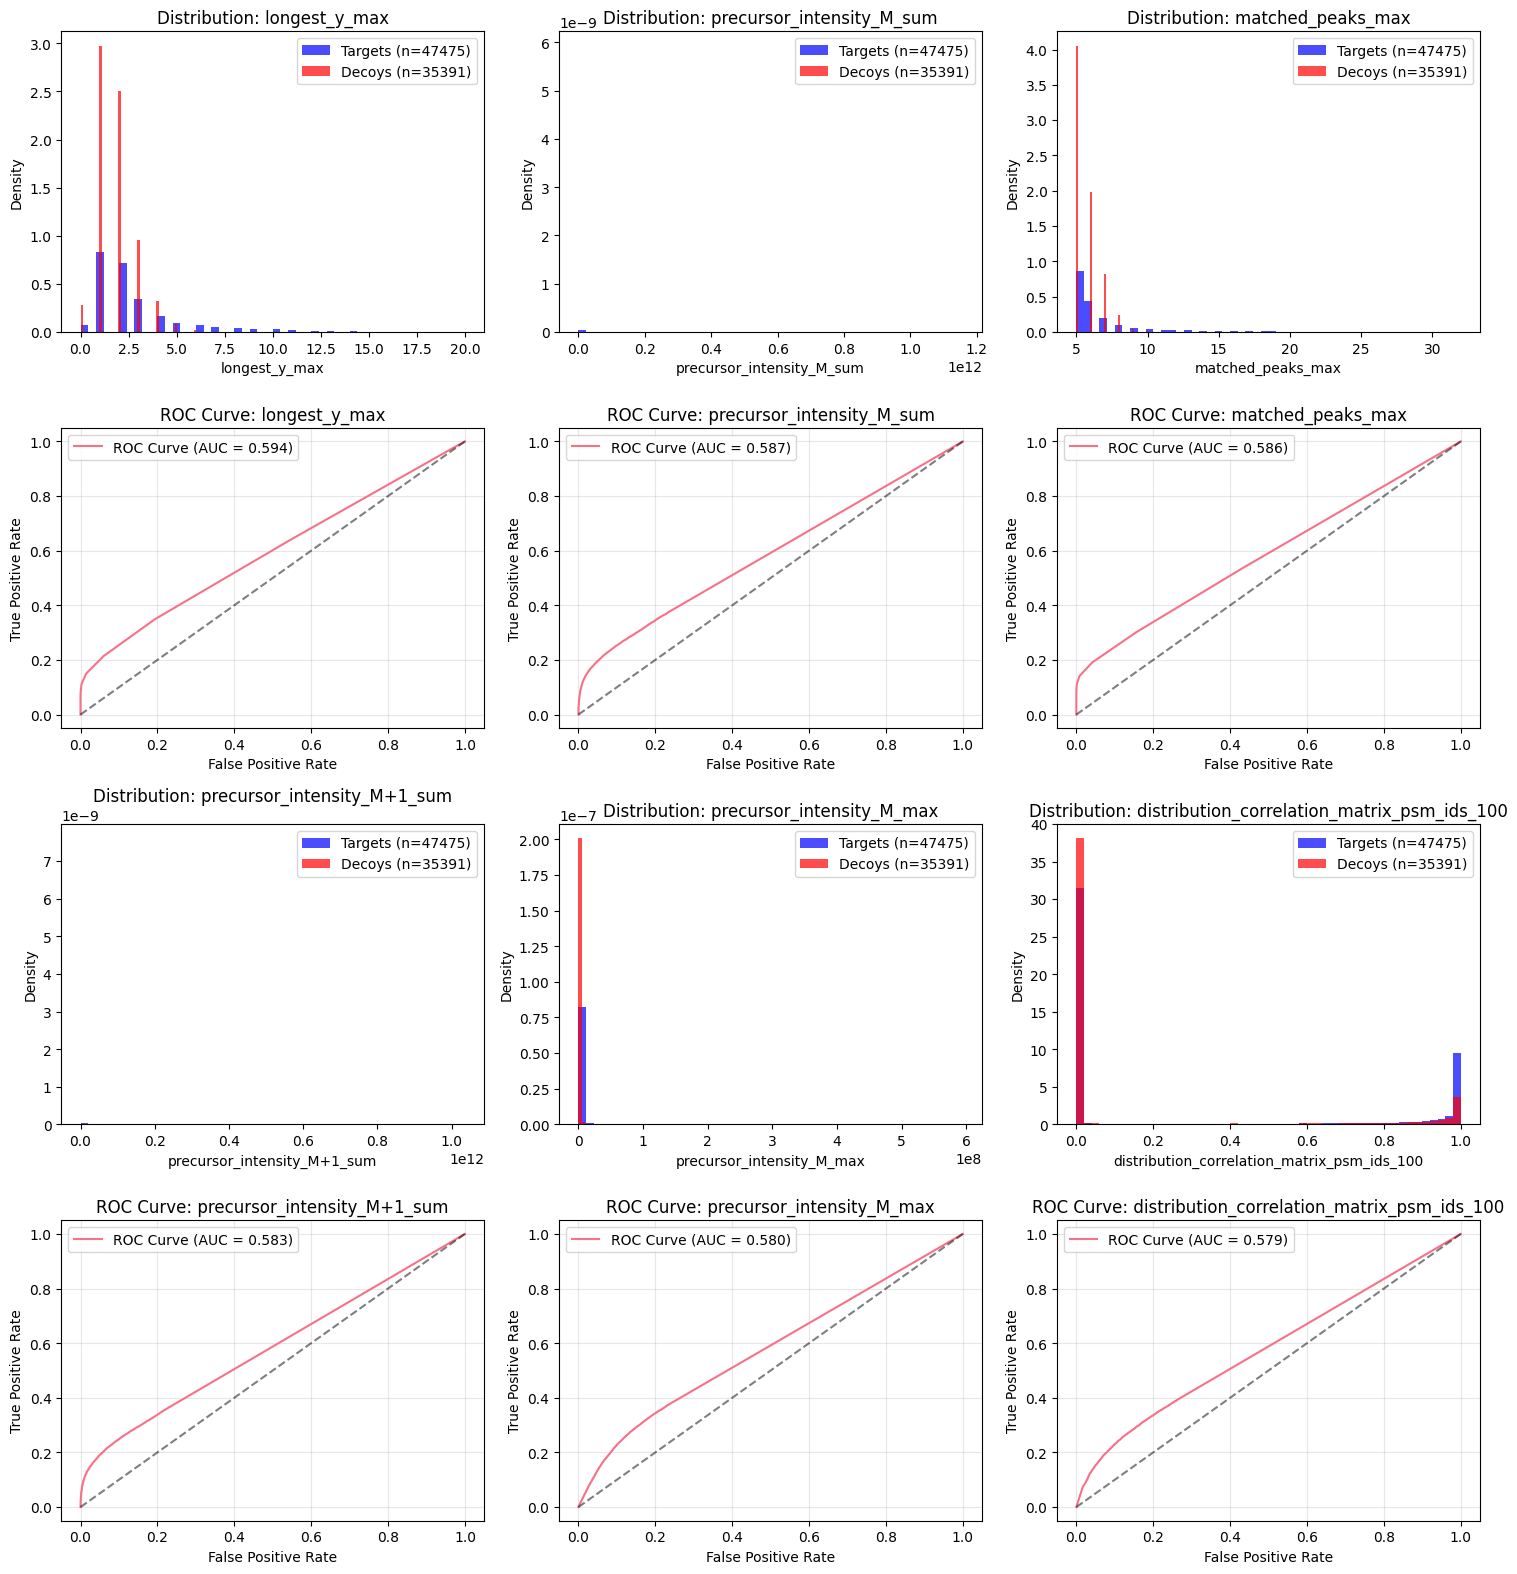

In [40]:
# Detailed analysis of top features
def plot_feature_details(df, feature_names, n_cols=3):
    """
    Plot detailed analysis for top features including distributions and ROC curves
    """
    n_features = len(feature_names)
    n_rows = (n_features + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows * 2, n_cols, figsize=(5 * n_cols, 4 * n_rows * 2))
    if n_rows == 1:
        axes = axes.reshape(2, -1)

    targets = df[df["Label"] == 1.0]
    decoys = df[df["Label"] == -1.0]

    for i, feature in enumerate(feature_names):
        row = (i // n_cols) * 2
        col = i % n_cols

        if row >= axes.shape[0] or col >= axes.shape[1]:
            break

        # Distribution plot
        ax_dist = axes[row, col]
        target_vals = targets[feature].dropna()
        decoy_vals = decoys[feature].dropna()

        ax_dist.hist(
            target_vals,
            bins=50,
            alpha=0.7,
            label=f"Targets (n={len(target_vals)})",
            density=True,
            color="blue",
        )
        ax_dist.hist(
            decoy_vals,
            bins=50,
            alpha=0.7,
            label=f"Decoys (n={len(decoy_vals)})",
            density=True,
            color="red",
        )
        ax_dist.set_xlabel(feature)
        ax_dist.set_ylabel("Density")
        ax_dist.set_title(f"Distribution: {feature}")
        ax_dist.legend()

        # ROC curve
        ax_roc = axes[row + 1, col]
        try:
            y_true = [1] * len(target_vals) + [0] * len(decoy_vals)
            y_score = list(target_vals) + list(decoy_vals)
            fpr, tpr, _ = roc_curve(y_true, y_score)
            auc_score = auc(fpr, tpr)

            ax_roc.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.3f})")
            ax_roc.plot([0, 1], [0, 1], "k--", alpha=0.5)
            ax_roc.set_xlabel("False Positive Rate")
            ax_roc.set_ylabel("True Positive Rate")
            ax_roc.set_title(f"ROC Curve: {feature}")
            ax_roc.legend()
            ax_roc.grid(True, alpha=0.3)
        except:
            ax_roc.text(
                0.5,
                0.5,
                "ROC curve\nnot available",
                ha="center",
                va="center",
                transform=ax_roc.transAxes,
            )

    # Remove empty subplots
    for i in range(len(feature_names), n_rows * n_cols):
        row = (i // n_cols) * 2
        col = i % n_cols
        if row < axes.shape[0] and col < axes.shape[1]:
            fig.delaxes(axes[row, col])
            fig.delaxes(axes[row + 1, col])

    plt.tight_layout()
    plt.show()


# Get top 6 features by AUC score for detailed analysis
top_features = feature_analysis.head(6)["feature"].tolist()
print("Detailed analysis of top 6 features by AUC score:")
print(top_features)
plot_feature_details(df, top_features, n_cols=3)

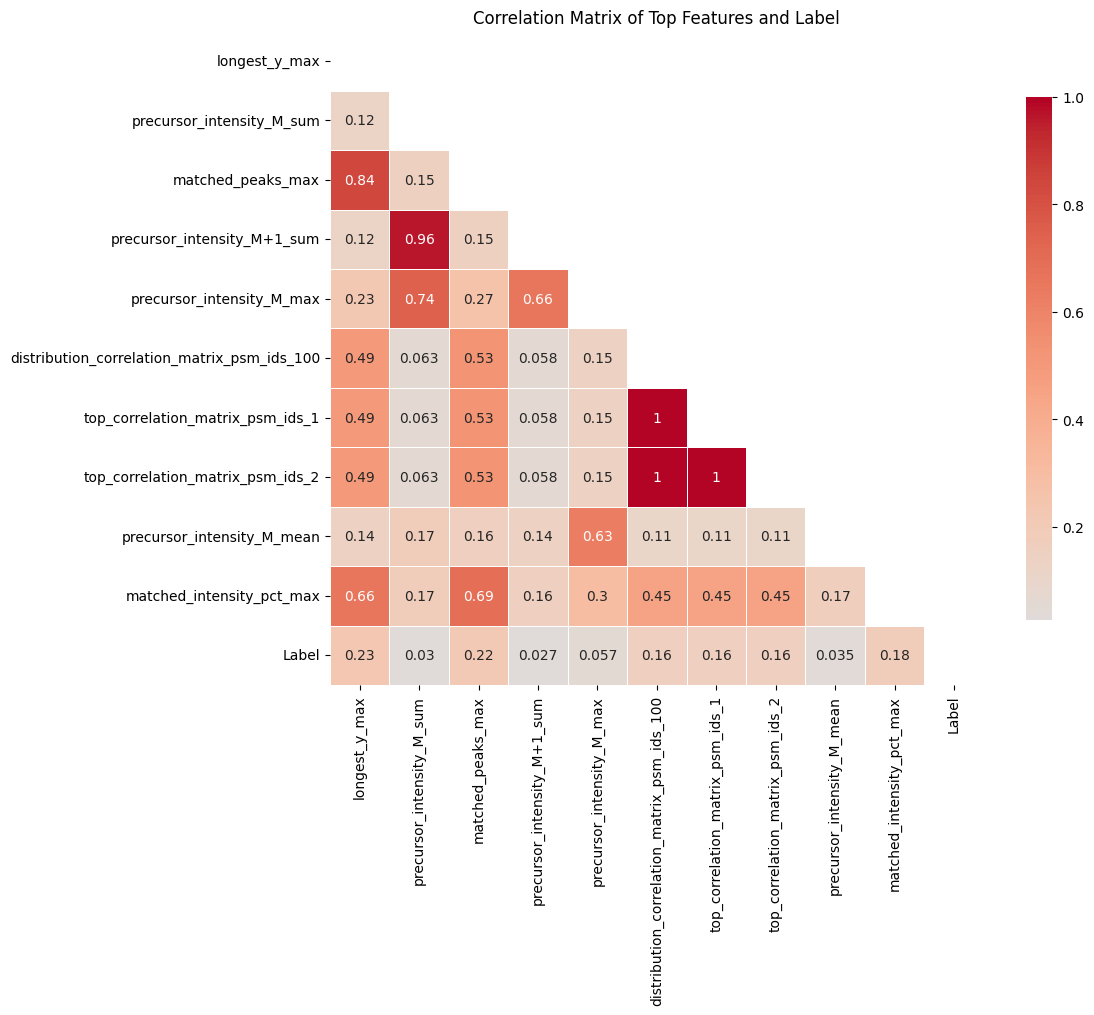

Highly correlated feature pairs (|r| > 0.7):
  longest_y_max - matched_peaks_max: 0.835
  precursor_intensity_M_sum - precursor_intensity_M+1_sum: 0.964
  precursor_intensity_M_sum - precursor_intensity_M_max: 0.742
  distribution_correlation_matrix_psm_ids_100 - top_correlation_matrix_psm_ids_1: 1.000
  distribution_correlation_matrix_psm_ids_100 - top_correlation_matrix_psm_ids_2: 1.000
  top_correlation_matrix_psm_ids_1 - top_correlation_matrix_psm_ids_2: 1.000


In [41]:
# Correlation analysis among top features
def analyze_feature_correlations(df, top_features):
    """
    Analyze correlations among top features to identify redundancy
    """
    # Calculate correlation matrix
    corr_matrix = df[top_features + ["Label"]].corr()

    # Plot correlation heatmap
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(
        corr_matrix,
        mask=mask,
        annot=True,
        cmap="coolwarm",
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8},
    )
    plt.title("Correlation Matrix of Top Features and Label")
    plt.tight_layout()
    plt.show()

    # Find highly correlated feature pairs
    high_corr_pairs = []
    for i in range(len(top_features)):
        for j in range(i + 1, len(top_features)):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) > 0.7:  # High correlation threshold
                high_corr_pairs.append((top_features[i], top_features[j], corr_val))

    if high_corr_pairs:
        print("Highly correlated feature pairs (|r| > 0.7):")
        for feat1, feat2, corr in high_corr_pairs:
            print(f"  {feat1} - {feat2}: {corr:.3f}")
    else:
        print("No highly correlated feature pairs found (|r| > 0.7)")

    return corr_matrix


# Analyze correlations for top 10 features
top_10_features = feature_analysis.head(10)["feature"].tolist()
corr_matrix = analyze_feature_correlations(df, top_10_features)

2D scatter plots for top feature combinations:


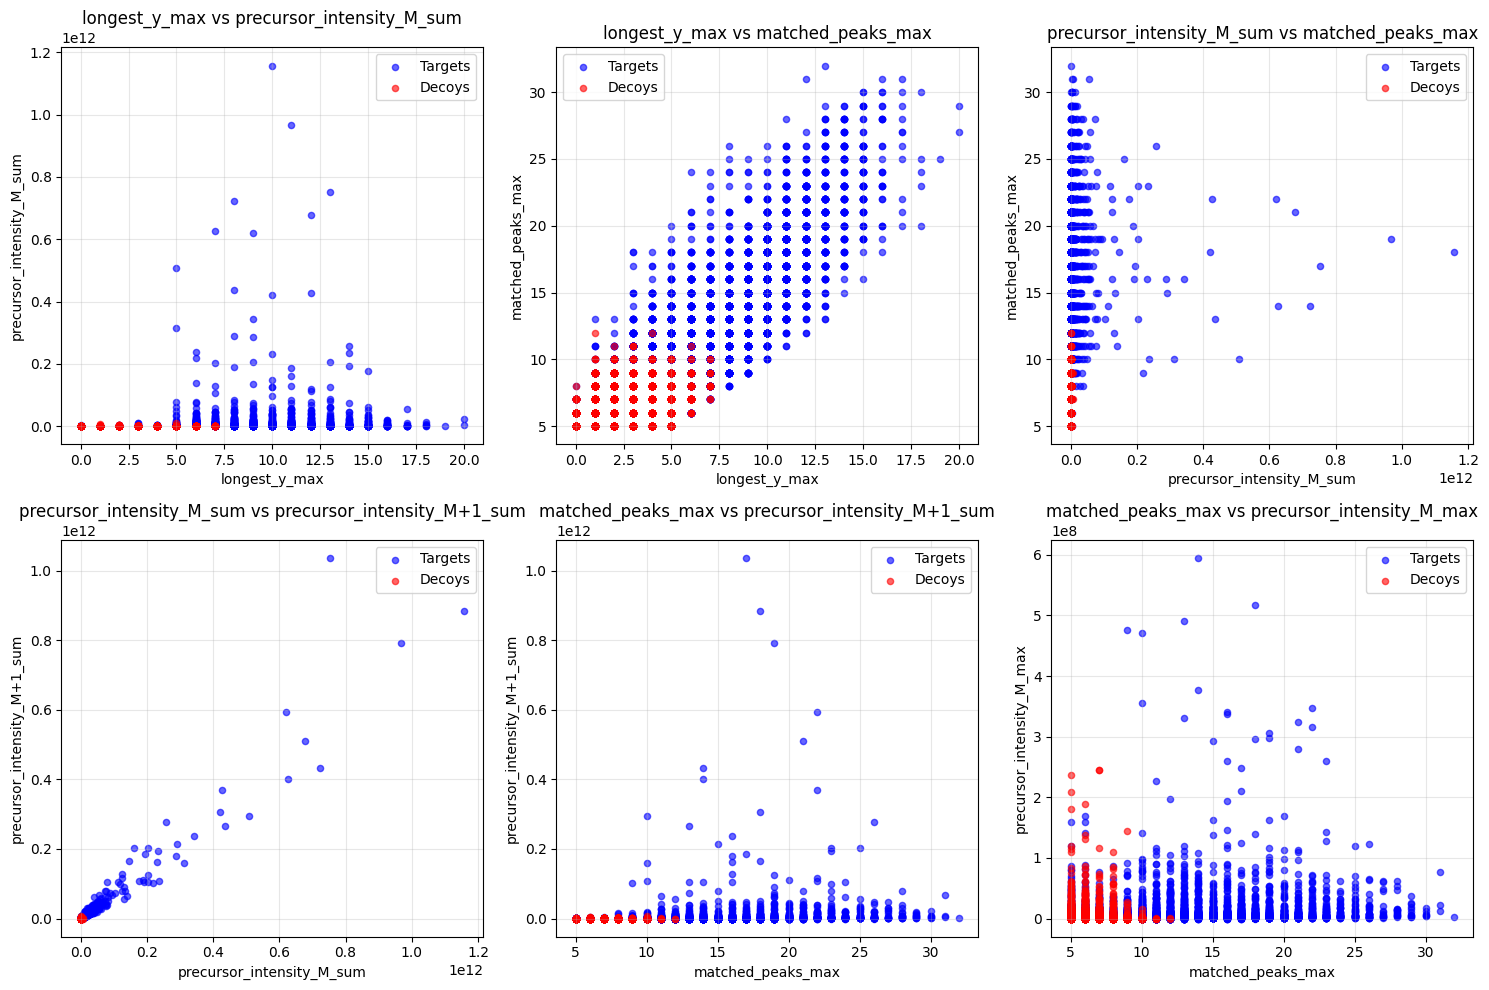

In [42]:
# 2D scatter plots for top feature combinations
def plot_feature_combinations(df, feature_pairs, figsize=(15, 10)):
    """
    Plot 2D scatter plots for feature combinations showing target/decoy separation
    """
    n_pairs = len(feature_pairs)
    n_cols = 3
    n_rows = (n_pairs + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    if n_rows == 1:
        axes = axes.reshape(1, -1)

    targets = df[df["Label"] == 1.0]
    decoys = df[df["Label"] == -1.0]

    for i, (feat1, feat2) in enumerate(feature_pairs):
        row = i // n_cols
        col = i % n_cols

        if row >= axes.shape[0] or col >= axes.shape[1]:
            break

        ax = axes[row, col]

        # Plot targets and decoys
        ax.scatter(
            targets[feat1],
            targets[feat2],
            alpha=0.6,
            s=20,
            label="Targets",
            color="blue",
        )
        ax.scatter(
            decoys[feat1], decoys[feat2], alpha=0.6, s=20, label="Decoys", color="red"
        )

        ax.set_xlabel(feat1)
        ax.set_ylabel(feat2)
        ax.set_title(f"{feat1} vs {feat2}")
        ax.legend()
        ax.grid(True, alpha=0.3)

    # Remove empty subplots
    for i in range(len(feature_pairs), n_rows * n_cols):
        row = i // n_cols
        col = i % n_cols
        if row < axes.shape[0] and col < axes.shape[1]:
            fig.delaxes(axes[row, col])

    plt.tight_layout()
    plt.show()


# Select top 6 features for combination analysis
top_6_features = feature_analysis.head(6)["feature"].tolist()
feature_pairs = [
    (top_6_features[i], top_6_features[j])
    for i in range(len(top_6_features))
    for j in range(i + 1, min(i + 3, len(top_6_features)))
]  # Show first few combinations

print("2D scatter plots for top feature combinations:")
plot_feature_combinations(df, feature_pairs[:6])  # Show first 6 combinations

# Summary and Recommendations

This section provides a comprehensive summary of the feature analysis results.

In [43]:
# Comprehensive Summary
print("=" * 60)
print("FEATURE ANALYSIS SUMMARY")
print("=" * 60)

print(f"\nDataset Overview:")
print(f"  Total samples: {len(df)}")
print(f"  Targets: {len(df_targets)} ({len(df_targets)/len(df)*100:.1f}%)")
print(f"  Decoys: {len(df_decoys)} ({len(df_decoys)/len(df)*100:.1f}%)")
print(f"  Features analyzed: {len(feature_analysis)}")

print(f"\nRandom Forest Classification:")
print(f"  Accuracy: {rf_accuracy:.4f}")

print(f"\nTop 5 Features by Different Metrics:")
print("\nBy AUC Score (discriminative power):")
for i, row in feature_analysis.head(5).iterrows():
    print(f"  {row['feature']}: AUC={row['auc_score']:.4f}")

print(f"\nBy Effect Size (Cohen's d):")
top_effect = feature_analysis.nlargest(5, "cohens_d")
for i, row in top_effect.iterrows():
    print(f"  {row['feature']}: d={row['cohens_d']:.4f}")

print(f"\nBy Random Forest Importance:")
for i, row in importance_df.head(5).iterrows():
    print(f"  {row['feature']}: importance={row['importance']:.4f}")

# Create a final ranking combining multiple metrics
feature_analysis["combined_rank"] = (
    feature_analysis["auc_score"].rank(ascending=False) * 0.4
    + feature_analysis["cohens_d"].rank(ascending=False) * 0.3
    + (-np.log10(feature_analysis["mannwhitney_p"] + 1e-300)).rank(ascending=False)
    * 0.3
)

print(f"\nTop 10 Features by Combined Ranking:")
top_combined = feature_analysis.nsmallest(10, "combined_rank")
for i, row in top_combined.iterrows():
    print(
        f"  {i+1:2d}. {row['feature']: <30} (AUC: {row['auc_score']:.3f}, d: {row['cohens_d']:.3f})"
    )

# Export results
feature_analysis.to_csv("feature_separability_analysis.csv", index=False)
importance_df.to_csv("feature_importance_analysis.csv", index=False)
print(f"\nResults exported to CSV files for further analysis.")

FEATURE ANALYSIS SUMMARY

Dataset Overview:
  Total samples: 82866
  Targets: 47475 (57.3%)
  Decoys: 35391 (42.7%)
  Features analyzed: 106

Random Forest Classification:
  Accuracy: 0.6389

Top 5 Features by Different Metrics:

By AUC Score (discriminative power):
  longest_y_max: AUC=0.5942
  precursor_intensity_M_sum: AUC=0.5873
  matched_peaks_max: AUC=0.5864
  precursor_intensity_M+1_sum: AUC=0.5834
  precursor_intensity_M_max: AUC=0.5804

By Effect Size (Cohen's d):
  longest_y_max: d=0.4748
  matched_peaks_max: d=0.4554
  top_correlation_matrix_psm_ids_10: d=0.4515
  top_correlation_matrix_psm_ids_9: d=0.4515
  poisson_min: d=0.4515

By Random Forest Importance:
  peptide_q_min: importance=0.1085
  spectrum_q_min: importance=0.0854
  peptide_q_max: importance=0.0819
  peptide_q_mean: importance=0.0561
  poisson_min: importance=0.0477

Top 10 Features by Combined Ranking:
  14. longest_y_max                  (AUC: 0.594, d: 0.475)
  12. matched_peaks_max              (AUC: 0.586